In [65]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf


In [54]:
#load the dataset from the keras datasets

In [55]:
mnist = tf.keras.datasets.mnist

In [56]:
(X_train,y_train),(X_test,y_test)= mnist.load_data()

In [57]:
X_train.shape

(60000, 28, 28)

In [58]:
X_test.shape

(10000, 28, 28)

In [59]:
#scaling down the xvalues

In [60]:
X_train = tf.keras.utils.normalize(X_train,axis=1)
X_test = tf.keras.utils.normalize(X_test,axis=1)

In [61]:
X_train.shape

(60000, 28, 28)

In [63]:
model=tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(units=128,activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(units=128,activation=tf.nn.relu))
model.add(tf.keras.layers.Dense(units=10,activation=tf.nn.softmax))

In [67]:
#compiling

In [71]:
model.compile(optimizer='adam',loss="sparse_categorical_crossentropy",metrics=["accuracy"])

In [73]:
#we now fit the model

In [75]:
model.fit(X_train,y_train,epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8681 - loss: 0.4679
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9655 - loss: 0.1132
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9773 - loss: 0.0718


In [79]:
loss,accuracy = model.evaluate(X_test,y_test)
print(accuracy)
print(loss)
model.save('digits.keras')

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9669 - loss: 0.1097
0.9707000255584717
0.09567617624998093


In [81]:
#LOAD YOUR O HANDWRITTEN DATA

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
The result is MOST likely a :9


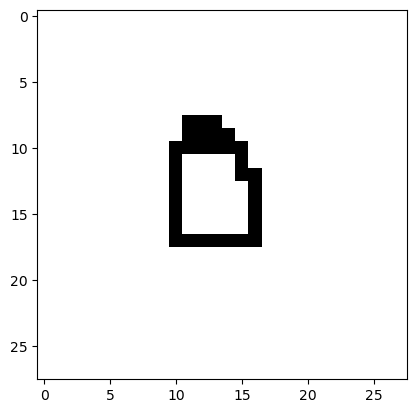

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
The result is MOST likely a :7


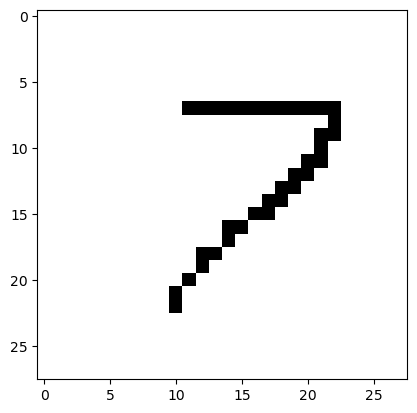

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
The result is MOST likely a :1


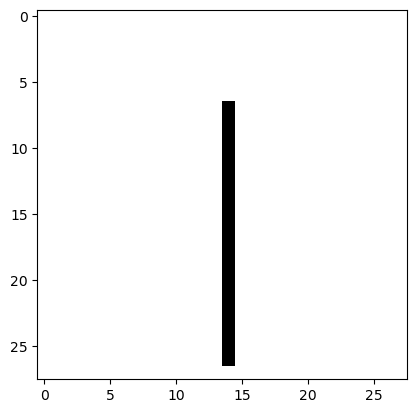

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
The result is MOST likely a :3


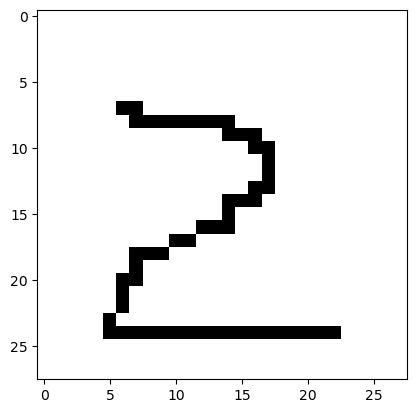

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
The result is MOST likely a :7


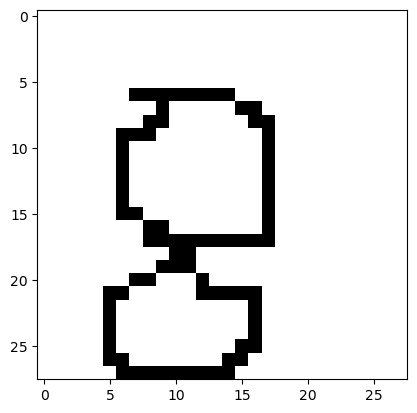

In [95]:
for x in range(1,6):
    img=cv.imread(f'{x}.png')[:,:,0]
    img=np.invert(np.array([img]))
    prediction = model.predict(img)
    print(f'The result is MOST likely a :{np.argmax(prediction)}')
    plt.imshow(img[0],cmap=plt.cm.binary)
    plt.show()